# 1. The Single Crane Lift Sequence Problem

## Tier 4 — Reinforcement Learning (RL) augmentation (DQN-style, runnable)

RL learns a policy by interacting with an environment.

To keep this notebook runnable everywhere (and easy to read), we use a **linear DQN-style model** (no PyTorch):

- Fixed action list (single or dual lift options)
- Epsilon-greedy exploration
- Experience replay
- Linear function approximation for Q-values

### Learning goals

- Understand the MDP view: state → action → reward → next state
- See how Q-learning improves over episodes
- Evaluate a greedy policy after training


In [1]:
# Environment check (no installs here)
#
# Best practice for classes: preinstall dependencies in the Docker/JupyterHub image.
# If you're running locally, install packages once in your environment.

try:
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
except ImportError as e:
    raise ImportError(
        "Missing dependency. Install: numpy, pandas, matplotlib. "
        "If you use the provided JupyterHub Docker image, these should already be installed."
    ) from e

rng = np.random.default_rng(0)
print("Dependencies imported successfully.")


Dependencies imported successfully.


In [2]:
# ----------------------------
# Imports + problem setup (Tier 4)
# ----------------------------
# Tier 4 is reinforcement learning (RL).
# Here we define:
# - the containers
# - the action space (possible single/dual lifts)
# - helper functions for feasibility and travel times

from dataclasses import dataclass
from itertools import combinations
from collections import deque
from typing import List, Tuple, Dict, Any


# ----------------------------
# Container representation
# ----------------------------
# In Tier 4 we simplify positions to a 1..6 index (like Tier 1).
@dataclass(frozen=True)
class Container:
    id: int
    pos: int
    weight: float


# Concrete 6-container instance
containers = [
    Container(1, 1, 8.5),
    Container(2, 2, 12.3),
    Container(3, 3, 15.7),
    Container(4, 4, 9.8),
    Container(5, 5, 11.2),
    Container(6, 6, 14.1),
]

id_to_container = {c.id: c for c in containers}


# ----------------------------
# Parameters (minutes)
# ----------------------------
HANDLE_SINGLE = 2.5
HANDLE_DUAL = 3.8
SETUP_TIME = 1.2
DUAL_WEIGHT_LIMIT = 20.0
TRAVEL_PER_UNIT = 0.8

START_POS = 1.0
START_MODE = 0  # 0 = single mode, 1 = dual mode


# ----------------------------
# Adjacency mapping (serpentine)
# ----------------------------
# We define a small 2x3 grid with serpentine numbering:
# Row 0: 1 2 3
# Row 1: 6 5 4
#
# This is used to determine which positions are adjacent.
pos_to_rc = {
    1: (0, 0),
    2: (0, 1),
    3: (0, 2),
    4: (1, 2),
    5: (1, 1),
    6: (1, 0),
}


def are_adjacent(p1: int, p2: int) -> bool:
    """Return True if p1 and p2 are adjacent on the grid."""
    r1, c1 = pos_to_rc[p1]
    r2, c2 = pos_to_rc[p2]
    return abs(r1 - r2) + abs(c1 - c2) == 1


def travel_time(pos_from: float, pos_to: float) -> float:
    """Simple 1D travel time for the crane."""
    return TRAVEL_PER_UNIT * abs(pos_from - pos_to)


def dual_center(i: int, j: int) -> float:
    """Return the 1D center position used for a dual lift."""
    return (id_to_container[i].pos + id_to_container[j].pos) / 2.0


def dual_feasible(i: int, j: int) -> bool:
    """Dual lift feasibility: adjacent + weight limit."""
    return are_adjacent(id_to_container[i].pos, id_to_container[j].pos) and (
        id_to_container[i].weight + id_to_container[j].weight
    ) <= DUAL_WEIGHT_LIMIT


# ----------------------------
# Action space
# ----------------------------
# RL needs a fixed list of actions.
# We'll include:
# - all single lifts: ('S', container_id)
# - all dual lifts: ('D', i, j)
ALL_SINGLE = [("S", c.id) for c in containers]
ALL_DUAL = [("D", i, j) for i, j in combinations([c.id for c in containers], 2) if dual_feasible(i, j)]
ACTIONS = ALL_SINGLE + ALL_DUAL

# State vector size:
# - 6 numbers for which containers remain (mask)
# - 1 number for current position (normalized)
# - 1 number for current mode
STATE_SIZE = 6 + 1 + 1
ACTION_SIZE = len(ACTIONS)

STATE_SIZE, ACTION_SIZE, ACTIONS

(8, 6, [('S', 1), ('S', 2), ('S', 3), ('S', 4), ('S', 5), ('S', 6)])

## Environment dynamics

### Reward

We want to minimize time, so we use:

- `reward = - step_time`

This means:

- faster actions → less negative reward → better

### Invalid actions

If the agent chooses an action that is not possible (e.g., lifting an already-lifted container), we apply a large penalty to quickly teach the agent to avoid it.


In [3]:
# ----------------------------
# Environment functions
# ----------------------------
# In RL we need to define:
# - how we represent the state (vector)
# - which actions are valid
# - how the environment transitions when we take an action


def encode_state(remaining: set[int], pos: float, mode: int) -> np.ndarray:
    """Convert environment state into a numeric vector (for Q-value computation).

    State features:
    - mask[i] = 1 if container i+1 is still remaining, else 0
    - current position (normalized to roughly 0..1)
    - current mode (0 or 1)
    """

    # Remaining mask for containers 1..6
    mask = np.array([1.0 if (i in remaining) else 0.0 for i in range(1, 7)], dtype=np.float32)

    # Normalize position by dividing by max position (=6)
    pos_norm = np.array([pos / 6.0], dtype=np.float32)

    # Mode as a float feature
    mode_arr = np.array([float(mode)], dtype=np.float32)

    return np.concatenate([mask, pos_norm, mode_arr])


def valid_action_mask(remaining: set[int]) -> np.ndarray:
    """Return a 0/1 mask over ACTIONS specifying which actions are currently allowed."""

    mask = np.zeros((ACTION_SIZE,), dtype=np.float32)

    for k, act in enumerate(ACTIONS):
        if act[0] == "S":
            # Single action is valid if that container is still remaining
            if act[1] in remaining:
                mask[k] = 1.0
        else:
            # Dual action is valid if both containers are remaining
            if act[1] in remaining and act[2] in remaining:
                mask[k] = 1.0

    return mask


def step_env(remaining: set[int], pos: float, mode: int, action_idx: int):
    """Take an action and return the transition.

    Returns:
    - new_remaining, new_pos, new_mode
    - reward
    - done flag
    - info dict (for debugging / logging)
    """

    act = ACTIONS[action_idx]

    # Local helper: compute step cost
    def cost(lift_mode: int, target_pos: float) -> float:
        # Setup time only if we switch mode
        setup = SETUP_TIME if mode != lift_mode else 0.0

        # Handling time depends on lift type
        handle = HANDLE_DUAL if lift_mode == 1 else HANDLE_SINGLE

        # Total = travel + setup + handling
        return travel_time(pos, target_pos) + setup + handle

    info: Dict[str, Any] = {"action": act}

    # ----------------------------
    # Single action
    # ----------------------------
    if act[0] == "S":
        cid = act[1]

        # Invalid if already lifted
        if cid not in remaining:
            return remaining, pos, mode, -50.0, False, {**info, "invalid": True}

        target = float(id_to_container[cid].pos)
        step_time = cost(0, target)

        new_remaining = set(remaining)
        new_remaining.remove(cid)

        # Reward is negative time (we want to minimize time)
        reward = -step_time

        done = len(new_remaining) == 0
        return new_remaining, target, 0, reward, done, {**info, "step_time": step_time}

    # ----------------------------
    # Dual action
    # ----------------------------
    if act[0] == "D":
        i, j = act[1], act[2]

        # Invalid if any is missing or pair is not feasible
        if i not in remaining or j not in remaining or (not dual_feasible(i, j)):
            return remaining, pos, mode, -50.0, False, {**info, "invalid": True}

        target = dual_center(i, j)
        step_time = cost(1, target)

        new_remaining = set(remaining)
        new_remaining.remove(i)
        new_remaining.remove(j)

        reward = -step_time

        done = len(new_remaining) == 0
        return new_remaining, target, 1, reward, done, {**info, "step_time": step_time}

    raise ValueError("Unknown action")


# Quick sanity check
rem0 = set(range(1, 7))
s0 = encode_state(rem0, START_POS, START_MODE)
rem1, pos1, mode1, r1, done1, info1 = step_env(rem0, START_POS, START_MODE, 0)

(s0.shape, rem1, pos1, mode1, r1, done1, info1)

((8,),
 {2, 3, 4, 5, 6},
 1.0,
 0,
 -2.5,
 False,
 {'action': ('S', 1), 'step_time': 2.5})

## Linear DQN-style agent (why linear?)

In many RL tutorials, DQN uses a neural network (PyTorch / TensorFlow). Here we intentionally keep it simpler.

We approximate:

- `Q(s, a) = w_a · s + b_a`

### Why this is still useful

- You still get the full RL pipeline: replay buffer, TD targets, epsilon-greedy.
- You can inspect weights and understand what features matter.
- It runs quickly and reliably on most machines.


In [4]:
# ----------------------------
# Linear DQN-style agent (implementation)
# ----------------------------
# We implement a tiny Q-learning agent.
#
# Key idea:
# - For each action a, we approximate Q(s,a) with a linear function.
# - We update weights using the TD error.


class LinearDQN:
    def __init__(self, state_size: int, action_size: int, lr: float = 0.05, gamma: float = 0.98):
        # Sizes
        self.state_size = state_size
        self.action_size = action_size

        # Learning rate (step size) and discount factor
        self.lr = lr
        self.gamma = gamma

        # Weight matrix W: one row per action, one column per state feature
        # Bias vector b: one bias per action
        self.W = rng.normal(0, 0.1, size=(action_size, state_size)).astype(np.float32)
        self.b = np.zeros((action_size,), dtype=np.float32)

        # Replay memory: store past transitions to break correlations
        self.memory = deque(maxlen=20000)

    def q_values(self, s: np.ndarray) -> np.ndarray:
        """Compute Q(s,·) for all actions."""
        return (self.W @ s) + self.b

    def act(self, s: np.ndarray, valid_mask: np.ndarray, eps: float) -> int:
        """Epsilon-greedy policy.

        With probability eps: random valid action
        Otherwise: greedy action with highest Q
        """

        if rng.random() < eps:
            idxs = np.where(valid_mask > 0)[0]
            return int(rng.choice(idxs))

        q = self.q_values(s)

        # Mask invalid actions by giving them a very low value
        q = np.where(valid_mask > 0, q, -1e9)

        return int(np.argmax(q))

    def remember(self, s, a, r, s2, done, valid_mask2):
        """Store one transition in replay memory."""
        self.memory.append((s, a, r, s2, done, valid_mask2))

    def replay(self, batch_size: int = 64) -> float:
        """Sample random transitions and train.

        Returns mean squared TD error (a rough loss).
        """

        if len(self.memory) < batch_size:
            return 0.0

        batch = rng.choice(len(self.memory), size=batch_size, replace=False)
        losses = []

        for idx in batch:
            s, a, r, s2, done, valid_mask2 = self.memory[idx]

            # Current prediction
            q = self.q_values(s)

            # TD target
            target = float(r)
            if not done:
                q2 = self.q_values(s2)
                q2 = np.where(valid_mask2 > 0, q2, -1e9)
                target = float(r) + self.gamma * float(np.max(q2))

            # TD error
            err = target - float(q[a])

            # Gradient step for linear model:
            # Q(s,a) = W[a]·s + b[a]
            self.W[a] += self.lr * err * s
            self.b[a] += self.lr * err

            losses.append(err * err)

        return float(np.mean(losses))


# Create the agent
agent = LinearDQN(STATE_SIZE, ACTION_SIZE)

In [5]:
# ----------------------------
# Training loop
# ----------------------------
# We train by running many episodes.
# Each episode:
# - starts with all containers remaining
# - ends when all containers are lifted (done=True)


def run_episode(eps: float, train: bool = True, max_steps: int = 50):
    """Run one episode. If train=True, update the agent using replay."""

    remaining = set(range(1, 7))
    pos = START_POS
    mode = START_MODE

    total_reward = 0.0
    total_time = 0.0
    losses = []

    for _ in range(max_steps):
        # Encode state + valid actions
        s = encode_state(remaining, pos, mode)
        vmask = valid_action_mask(remaining)

        # Choose action
        a = agent.act(s, vmask, eps=eps)

        # Step environment
        remaining2, pos2, mode2, r, done, info = step_env(remaining, pos, mode, a)

        total_reward += float(r)
        if "step_time" in info:
            total_time += float(info["step_time"])

        # Next-state encoding
        s2 = encode_state(remaining2, pos2, mode2)
        vmask2 = valid_action_mask(remaining2)

        # Train from replay
        if train:
            agent.remember(s, a, r, s2, done, vmask2)
            loss = agent.replay(batch_size=64)
            losses.append(loss)

        # Update loop variables
        remaining, pos, mode = remaining2, pos2, mode2

        if done:
            break

    mean_loss = float(np.mean(losses) if losses else 0.0)
    return total_time, total_reward, mean_loss


# ----------------------------
# Run training
# ----------------------------
episodes = 450

# Exploration schedule
# Start very random, then slowly become greedy.
eps0 = 1.0
eps_min = 0.05

# Multiply epsilon by this each episode
# (close to 1.0 means slow decay)
decay = 0.993

# Logs
ep_times, ep_rewards, ep_losses = [], [], []

eps = eps0
for ep in range(episodes):
    t, r, loss = run_episode(eps=eps, train=True)
    ep_times.append(t)
    ep_rewards.append(r)
    ep_losses.append(loss)

    # Decay epsilon
    eps = max(eps_min, eps * decay)

print("Training finished.")
print(f"Final epsilon: {eps:.3f}")
print(f"Last-20 avg time: {np.mean(ep_times[-20:]):.3f} min")

Training finished.
Final epsilon: 0.050
Last-20 avg time: 19.320 min


## Training curves

### How to read these plots

- **Episode total time** should generally decrease over training.
- **Episode reward** should generally increase (less negative).
- **TD loss** may be noisy; the key is that learning is stable (not exploding).

If curves are unstable, try:

- lowering the learning rate
- increasing replay buffer size
- increasing episodes


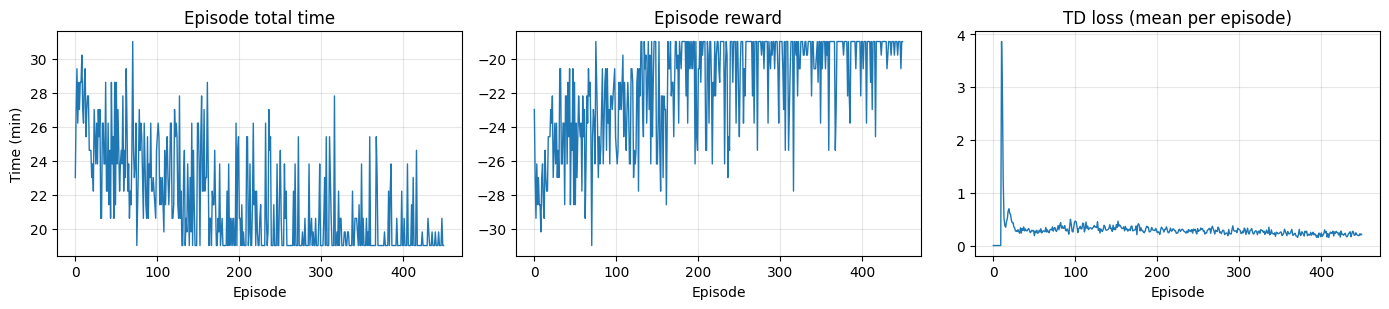

In [6]:
# ----------------------------
# Plot training curves
# ----------------------------
# We plot 3 things:
# - total time per episode (should generally go down)
# - total reward per episode (should generally go up)
# - TD loss (noisy is okay, but should be stable)

fig, axes = plt.subplots(1, 3, figsize=(14, 3.2))

axes[0].plot(ep_times, lw=1)
axes[0].set_title("Episode total time")
axes[0].set_xlabel("Episode")
axes[0].set_ylabel("Time (min)")
axes[0].grid(True, alpha=0.3)

axes[1].plot(ep_rewards, lw=1)
axes[1].set_title("Episode reward")
axes[1].set_xlabel("Episode")
axes[1].grid(True, alpha=0.3)

axes[2].plot(ep_losses, lw=1)
axes[2].set_title("TD loss (mean per episode)")
axes[2].set_xlabel("Episode")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Greedy evaluation (after training)

Now we run one episode with `eps = 0` (no exploration) to see what policy the agent has learned.

The table shows:

- the chosen action
- step time
- remaining containers after the action


In [7]:
# ----------------------------
# Evaluate greedy policy (eps = 0)
# ----------------------------
# After training, we freeze exploration and see what the agent does.


def evaluate_greedy():
    remaining = set(range(1, 7))
    pos = START_POS
    mode = START_MODE

    log = []
    total_time = 0.0

    for _ in range(50):
        # State -> greedy action
        s = encode_state(remaining, pos, mode)
        vmask = valid_action_mask(remaining)
        a = agent.act(s, vmask, eps=0.0)

        # Step
        remaining2, pos2, mode2, r, done, info = step_env(remaining, pos, mode, a)

        # Log step
        log.append(
            {
                "action": info["action"],
                "step_time": info.get("step_time", None),
                "remaining": sorted(list(remaining2)),
            }
        )

        if "step_time" in info:
            total_time += float(info["step_time"])

        # Update
        remaining, pos, mode = remaining2, pos2, mode2

        if done:
            break

    return total_time, pd.DataFrame(log)


greedy_time, greedy_df = evaluate_greedy()
print(f"Greedy policy total time: {greedy_time:.3f} min")

greedy_df

Greedy policy total time: 19.000 min


,action,step_time,remaining
0,"(S, 1)",2.5,"[2, 3, 4, 5, 6]"
1,"(S, 2)",3.3,"[3, 4, 5, 6]"
2,"(S, 3)",3.3,"[4, 5, 6]"
3,"(S, 4)",3.3,"[5, 6]"
4,"(S, 5)",3.3,[6]
5,"(S, 6)",3.3,[]


## Additional operational visualizations (logistics-focused)

In logistics, model evaluation is easier when we can visualize outputs.

Below we analyze the **greedy evaluation run** (after training) with:

- step-by-step duration bars
- cumulative completion time
- action type counts (single vs dual)

These are derived from `greedy_df` and `greedy_time` computed above.

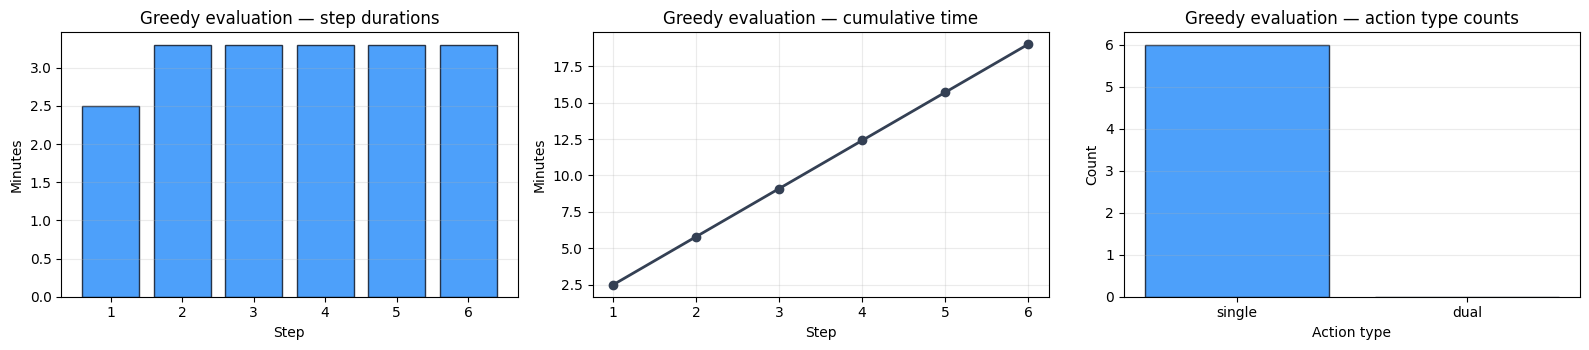

In [8]:
# ----------------------------
# Visualize greedy policy behavior
# ----------------------------
# `greedy_df` contains a row per decision.
# We'll extract:
# - action type (S or D)
# - step time
# and build plots.

vis = greedy_df.copy()

# Extract action type: ('S', id) or ('D', i, j)
vis["action_type"] = vis["action"].apply(lambda a: a[0])

# Convert to nicer labels
vis["action_label"] = vis["action_type"].map({"S": "single", "D": "dual"})

# Step index
vis.index = np.arange(1, len(vis) + 1)
vis["step"] = vis.index.astype(int)

# Some steps could be invalid (then step_time is None). Filter valid ones.
vis_valid = vis.dropna(subset=["step_time"]).copy()
vis_valid["step_time"] = vis_valid["step_time"].astype(float)

# Cumulative time
vis_valid["cum_time"] = vis_valid["step_time"].cumsum()

# Colors
color_map = {"single": "#2E90FA", "dual": "#12B76A"}
colors = [color_map[x] for x in vis_valid["action_label"].tolist()]

fig, axes = plt.subplots(1, 3, figsize=(16, 3.6))

# (1) Step durations
axes[0].bar(vis_valid["step"], vis_valid["step_time"], color=colors, edgecolor="#101828", alpha=0.85)
axes[0].set_title("Greedy evaluation — step durations")
axes[0].set_xlabel("Step")
axes[0].set_ylabel("Minutes")
axes[0].grid(True, axis="y", alpha=0.25)

# (2) Cumulative time
axes[1].plot(vis_valid["step"], vis_valid["cum_time"], marker="o", lw=2, color="#344054")
axes[1].set_title("Greedy evaluation — cumulative time")
axes[1].set_xlabel("Step")
axes[1].set_ylabel("Minutes")
axes[1].grid(True, alpha=0.25)

# (3) Action type counts
counts = vis_valid["action_label"].value_counts().reindex(["single", "dual"]).fillna(0)
axes[2].bar(counts.index, counts.values, color=[color_map["single"], color_map["dual"]], edgecolor="#101828", alpha=0.85)
axes[2].set_title("Greedy evaluation — action type counts")
axes[2].set_xlabel("Action type")
axes[2].set_ylabel("Count")
axes[2].grid(True, axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

## Why this Tier exists vs earlier Tiers (comparison)

### Why Tier 4 exists (vs Tier 1–3)

Tier 1–3 are “solve once” approaches:

- DP solves optimally (small instances)
- greedy builds a schedule quickly
- GA searches for a near-optimal schedule by repeated evaluation

Tier 4 exists for settings where you want a policy that can **generalize**:

- new instances
- changing conditions
- repeated decision-making

Instead of solving each instance from scratch, RL tries to learn *how to decide*.

### Advantages vs Tier 1–3

- Can reuse a learned policy across many similar instances
- Naturally handles sequential decision making (state → action → reward → next state)
- Can adapt online (continue learning if the environment changes)

### Disadvantages vs Tier 1–3

- Training can be unstable and requires many episodes
- Sensitive to reward design and state representation
- Harder to guarantee solution quality than DP
- Requires more engineering to become production-ready

### When to use Tier 4

- You repeatedly solve similar scheduling problems (stream of instances)
- You want a decision policy rather than a one-off optimizer
- You have simulation data to train on and can evaluate policies safely
